Using device: cuda


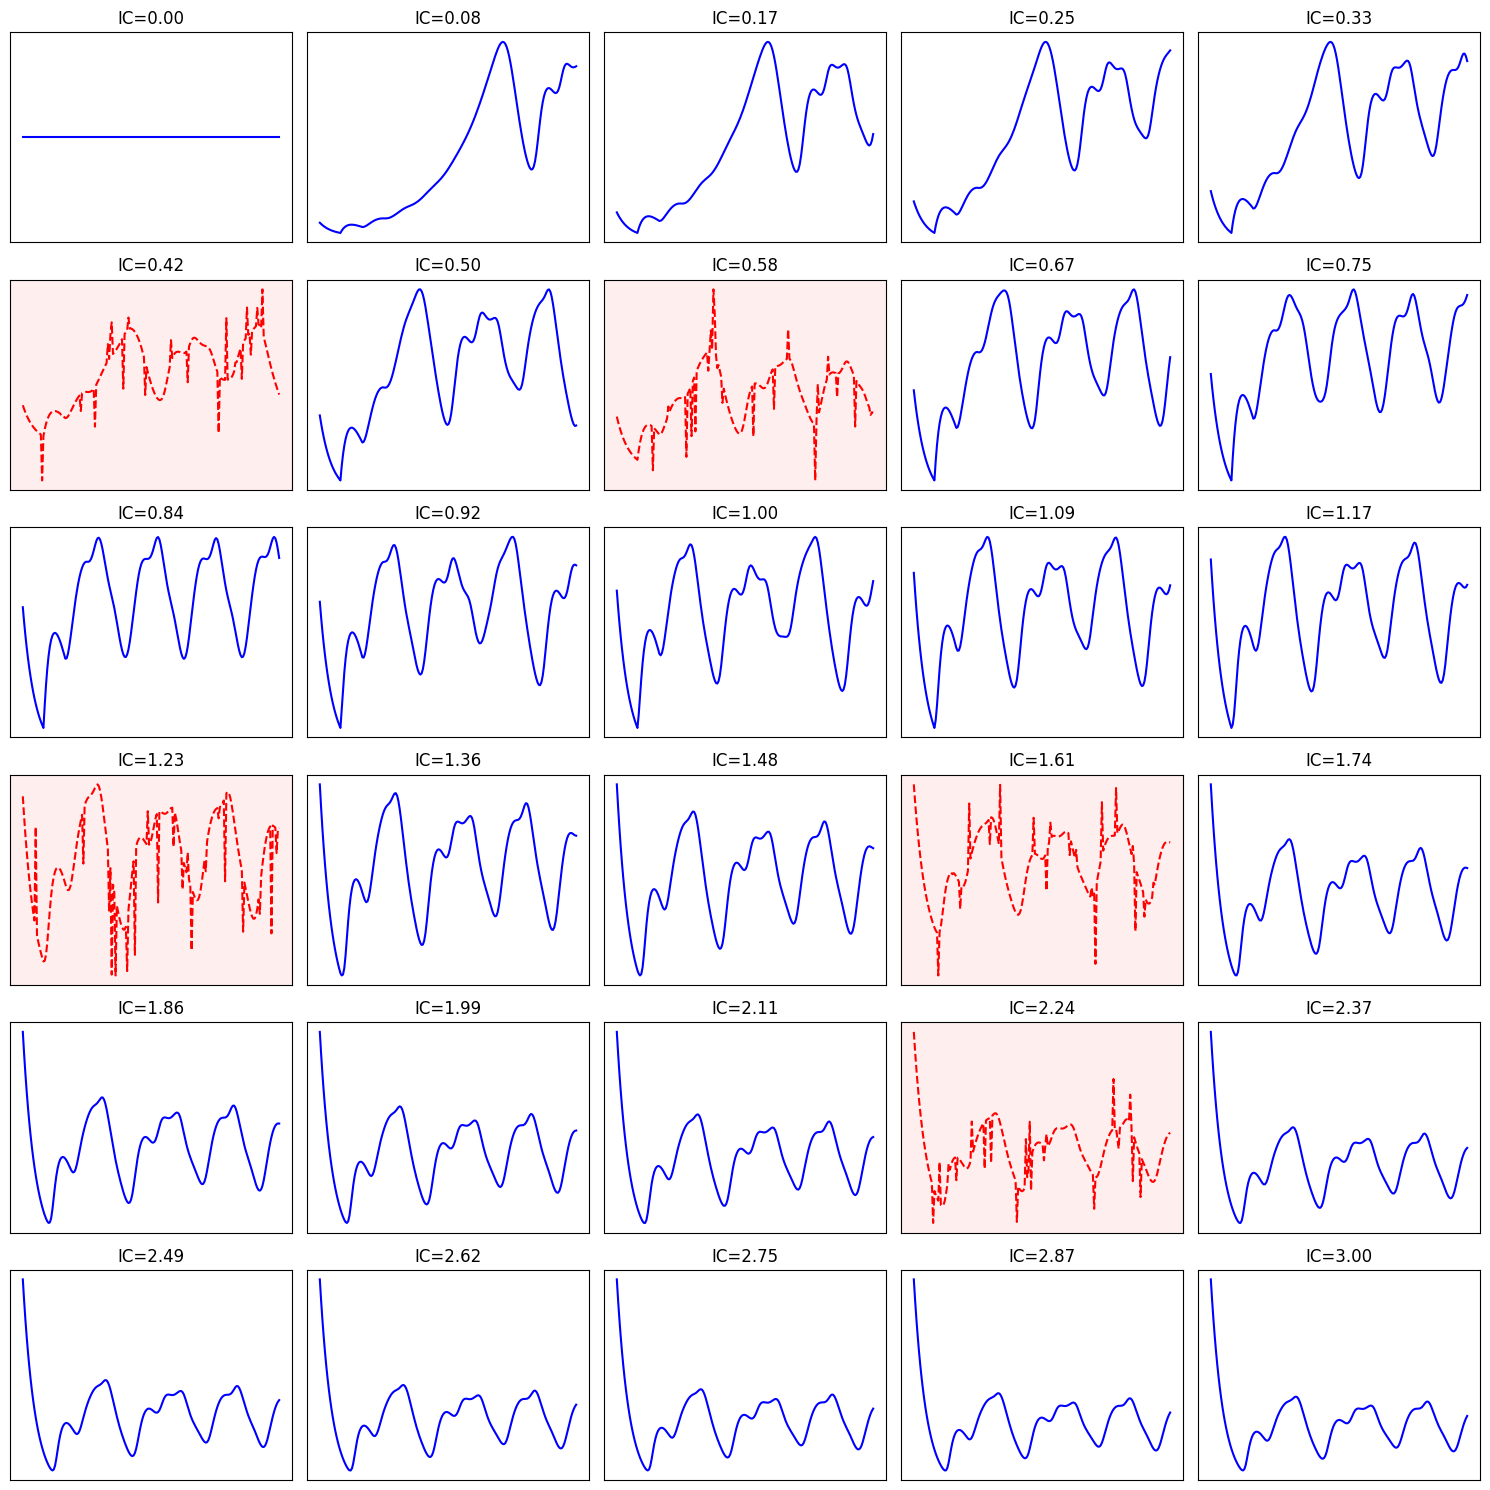

Epoch 000: Train Loss = 4.4686, Val Loss = 0.2694
Epoch 001: Train Loss = 1.5812, Val Loss = 0.2347
Epoch 002: Train Loss = 1.2600, Val Loss = 0.1086
Epoch 003: Train Loss = 1.1597, Val Loss = 0.0985
Epoch 004: Train Loss = 1.0178, Val Loss = 0.0911
Epoch 005: Train Loss = 0.9906, Val Loss = 0.0847
Epoch 006: Train Loss = 0.9532, Val Loss = 0.0756
Epoch 007: Train Loss = 0.9033, Val Loss = 0.0662
Epoch 008: Train Loss = 1.1597, Val Loss = 0.0622
Epoch 009: Train Loss = 0.9196, Val Loss = 0.0919
Epoch 010: Train Loss = 0.9234, Val Loss = 0.0599
Epoch 011: Train Loss = 0.9446, Val Loss = 0.0552
Epoch 012: Train Loss = 0.8653, Val Loss = 0.0664
Epoch 013: Train Loss = 0.8121, Val Loss = 0.0475
Epoch 014: Train Loss = 0.8387, Val Loss = 0.0498
Epoch 015: Train Loss = 0.8068, Val Loss = 0.0529
Epoch 016: Train Loss = 0.7952, Val Loss = 0.0590
Epoch 017: Train Loss = 0.7881, Val Loss = 0.0510
Epoch 018: Train Loss = 0.7792, Val Loss = 0.0585
Epoch 019: Train Loss = 0.7896, Val Loss = 0.0541


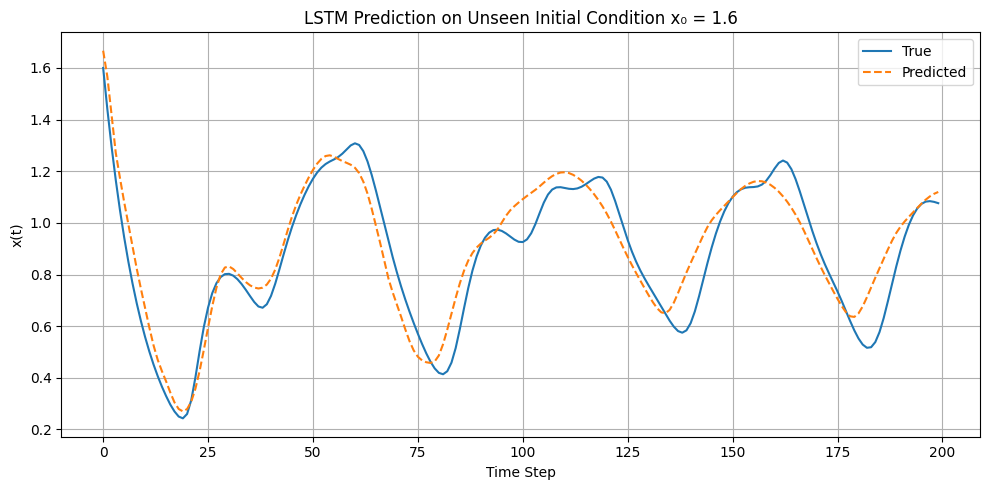

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import time
import torch
import numpy as np
import random

# --- 1. Fix Python, NumPy, and random seeds ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# --- 2. Force deterministic behavior for cuDNN ---
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Use GPU if available ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x
# --- Function to insert anomalies ---
def insert_anomalies(x, anomaly_rate=0.05, anomaly_scale=0.5):
    """
    Insert anomalies into a time series.
    anomaly_rate: fraction of points that are anomalous
    anomaly_scale: magnitude of anomalies
    """
    x_anom = x.copy()
    n_points = len(x)
    n_anomalies = int(n_points * anomaly_rate)

    anomaly_indices = np.random.choice(n_points, size=n_anomalies, replace=False)
    for idx in anomaly_indices:
        x_anom[idx] += np.random.uniform(-anomaly_scale, anomaly_scale)
    return x_anom

# --- Parameters ---
t_max = 200
delta_t = 1
train_ics_left = np.linspace(0, 1.17, 15)
train_ics_right = np.linspace(1.23, 3, 15)
train_ics = np.concatenate((train_ics_left, train_ics_right))
test_ic = 1.6
timesteps = np.arange(0, t_max, delta_t)

# --- Generate training data (with anomalies on 5 sequences) ---
X_list, y_list = [], []
rng = np.random.default_rng()  # independent generator (no fixed seed)
anomalous_indices = [15, 5, 23, 7, 18]

for i, ic in enumerate(train_ics):
    x = mackey_glass(t_max=t_max, x0=ic)
    if i in anomalous_indices:
        x = insert_anomalies(x, anomaly_rate=0.1, anomaly_scale=0.7)  # insert anomalies
    norm_t = timesteps / t_max
    features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
    X_list.append(features)
    y_list.append(x)

X = np.vstack(X_list)
y = np.concatenate(y_list)

import math

# Number of rows and columns for subplot grid
n_traj = len(y_list)
n_cols = 5  # you can change this
n_rows = math.ceil(n_traj / n_cols)

plt.figure(figsize=(n_cols*3, n_rows*2.5))

for i, x in enumerate(y_list):
    plt.subplot(n_rows, n_cols, i+1)
    if i in anomalous_indices:
        plt.plot(x, 'r--', label=f"IC={train_ics[i]:.2f} (Anomalous)")
    else:
        plt.plot(x, 'b-', label=f"IC={train_ics[i]:.2f}")
    plt.title(f"IC={train_ics[i]:.2f}")
    plt.xticks([])
    plt.yticks([])
    if i in anomalous_indices:
        plt.gca().set_facecolor("#ffeeee")  # light red background for anomalies

plt.tight_layout()
plt.show()



# --- Generate test data ---
x_test = mackey_glass(t_max=200, x0=test_ic)
norm_t_test = timesteps / t_max
X_test = np.stack([np.full_like(norm_t_test, test_ic), norm_t_test], axis=1)
y_test = x_test

# --- Normalize features ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

# --- Prepare torch datasets ---
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).reshape(len(train_ics), t_max, 2)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(len(train_ics), t_max)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(0).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(0).to(device)

# Split into train and validation (36 train, 4 val)
val_split = 1
train_len = len(train_ics) - val_split
train_dataset, val_dataset = random_split(TensorDataset(X_tensor, y_tensor), [train_len, val_split])
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

# --- LSTM model ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=3):
        super(LSTMNet, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out).squeeze(-1)
        return out

model = LSTMNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Early stopping params ---
best_val_loss = float('inf')
patience = 40
patience_counter = 0
best_model_state = None

# --- Train the model ---
epochs = 200
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = model(xb)
        loss = criterion(output, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation loss
    model.eval()
    with torch.no_grad():
        val_loss = 0
        for xb_val, yb_val in val_loader:
            xb_val, yb_val = xb_val.to(device), yb_val.to(device)
            val_output = model(xb_val)
            val_loss += criterion(val_output, yb_val).item()
        val_loss /= len(val_loader)

    print(f"Epoch {epoch:03d}: Train Loss = {total_loss:.4f}, Val Loss = {val_loss:.4f}")

    # Check early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# --- Load best model ---
model.load_state_dict(best_model_state)
start_time = time.time()
# --- Predict on test IC ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).squeeze(0).cpu().numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"Test R²:   {r2:.4f}")
end_time = time.time()
# --- Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"LSTM Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()